# Logistic Regression

Train Logistic Regression on the processed classification dataset and report Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

ROOT_DIR = Path.cwd().parents[1] if Path.cwd().name == "Logistic Regression" else Path.cwd()
DATA_DIR = ROOT_DIR / "data" / "classification"
OUTPUT_DIR = ROOT_DIR / "train" / "Logistic Regression" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLUMN = "readmitted_binary"
RANDOM_STATE = 42

DATA_DIR, OUTPUT_DIR

(WindowsPath('d:/HocTap/KT&XLTT/CUOIKI/data/classification'),
 WindowsPath('d:/HocTap/KT&XLTT/CUOIKI/train/Logistic Regression/outputs'))

In [2]:
train_df = pd.read_csv(DATA_DIR / "classification_train_processed.csv")
val_df = pd.read_csv(DATA_DIR / "classification_validation_processed.csv")
test_df = pd.read_csv(DATA_DIR / "classification_test_processed.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("Target distribution in train:")
print(train_df[TARGET_COLUMN].value_counts(normalize=True).rename("ratio"))

Train: (65128, 292)
Validation: (16282, 292)
Test: (20353, 292)
Target distribution in train:
readmitted_binary
0    0.539108
1    0.460892
Name: ratio, dtype: float64


In [3]:
X_train = train_df.drop(columns=[TARGET_COLUMN])
y_train = train_df[TARGET_COLUMN]

X_val = val_df.drop(columns=[TARGET_COLUMN])
y_val = val_df[TARGET_COLUMN]

X_test = test_df.drop(columns=[TARGET_COLUMN])
y_test = test_df[TARGET_COLUMN]

X_train.shape, y_train.shape

((65128, 291), (65128,))

In [4]:
import time

model = LogisticRegression(
    max_iter=3000,
    solver="saga",
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds")
print(f"Number of iterations: {model.n_iter_[0]}")

c:\Users\ADMIN\anaconda3\envs\A3Net\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


convergence after 950 epochs took 137 seconds
Training completed in 137.71 seconds
Number of iterations: 950


In [5]:
def evaluate_model(model, X, y, split_name):
    y_pred = model.predict(X)

    metrics = {
        "split": split_name,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1_score": f1_score(y, y_pred, zero_division=0),
    }

    cm = confusion_matrix(y, y_pred)
    report = pd.DataFrame(classification_report(y, y_pred, output_dict=True, zero_division=0)).T
    return metrics, cm, report, y_pred


val_metrics, val_cm, val_report, val_pred = evaluate_model(model, X_val, y_val, "validation")
test_metrics, test_cm, test_report, test_pred = evaluate_model(model, X_test, y_test, "test")

metrics_df = pd.DataFrame([val_metrics, test_metrics])
metrics_df

,split,accuracy,precision,recall,f1_score
0,validation,0.634934,0.600984,0.618603,0.609666
1,test,0.636172,0.604462,0.609423,0.606932


In [6]:
print("Validation classification report")
display(val_report)

print("Test classification report")
display(test_report)

Validation classification report


,precision,recall,f1-score,support
0,0.665576,0.648895,0.657130,8778.000000
1,0.600984,0.618603,0.609666,7504.000000
accuracy,0.634934,0.634934,0.634934,0.634934
macro avg,0.633280,0.633749,0.633398,16282.000000
weighted avg,0.635807,0.634934,0.635255,16282.000000


Test classification report


,precision,recall,f1-score,support
0,0.663699,0.659041,0.661362,10972.000000
1,0.604462,0.609423,0.606932,9381.000000
accuracy,0.636172,0.636172,0.636172,0.636172
macro avg,0.634080,0.634232,0.634147,20353.000000
weighted avg,0.636396,0.636172,0.636275,20353.000000


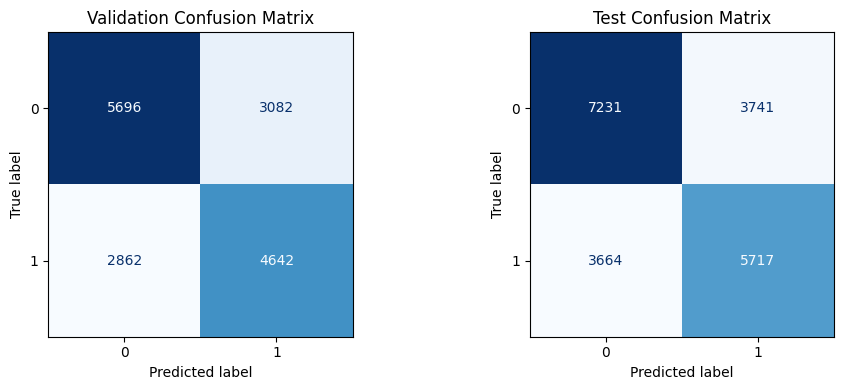

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(confusion_matrix=val_cm, display_labels=model.classes_).plot(
    ax=axes[0], values_format="d", cmap="Blues", colorbar=False
)
axes[0].set_title("Validation Confusion Matrix")

ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=model.classes_).plot(
    ax=axes[1], values_format="d", cmap="Blues", colorbar=False
)
axes[1].set_title("Test Confusion Matrix")

plt.tight_layout()
plt.show()

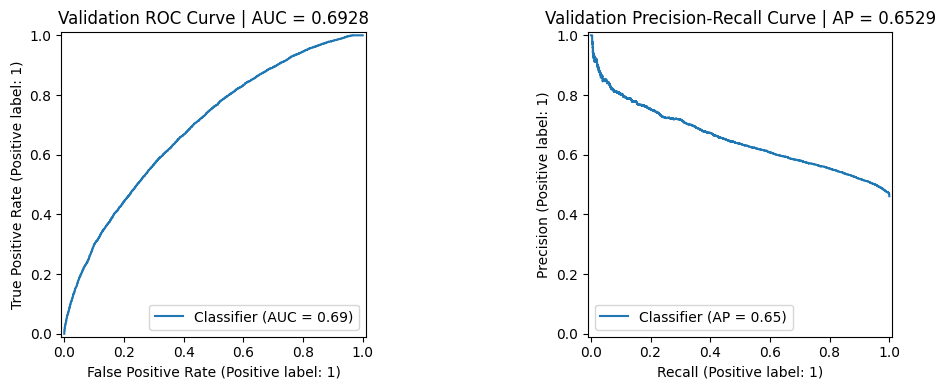

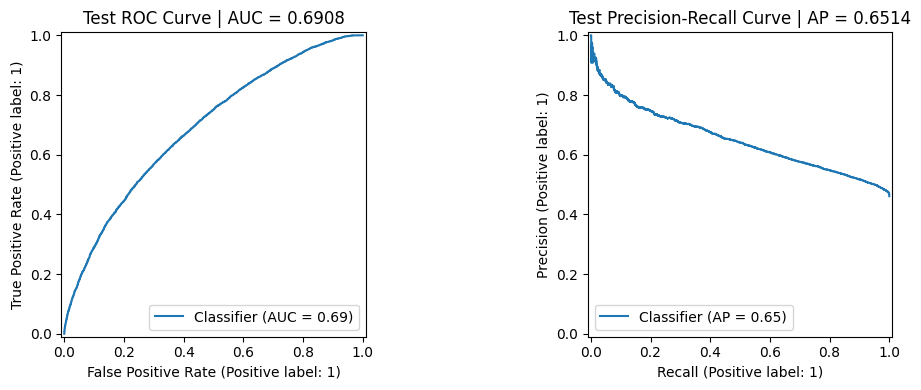

In [8]:
def plot_roc_and_pr_curves(model, X, y, split_name):
    y_score = model.predict_proba(X)[:, 1]

    roc_auc = roc_auc_score(y, y_score)
    avg_precision = average_precision_score(y, y_score)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    RocCurveDisplay.from_predictions(y, y_score, ax=axes[0])
    axes[0].set_title(f"{split_name} ROC Curve | AUC = {roc_auc:.4f}")

    PrecisionRecallDisplay.from_predictions(y, y_score, ax=axes[1])
    axes[1].set_title(f"{split_name} Precision-Recall Curve | AP = {avg_precision:.4f}")

    plt.tight_layout()
    plt.show()


plot_roc_and_pr_curves(model, X_val, y_val, "Validation")
plot_roc_and_pr_curves(model, X_test, y_test, "Test")

In [9]:
metrics_df.to_csv(OUTPUT_DIR / "metrics_summary.csv", index=False)
val_report.to_csv(OUTPUT_DIR / "validation_classification_report.csv")
test_report.to_csv(OUTPUT_DIR / "test_classification_report.csv")

pd.DataFrame(val_cm, index=["actual_0", "actual_1"], columns=["predicted_0", "predicted_1"]).to_csv(
    OUTPUT_DIR / "validation_confusion_matrix.csv"
)
pd.DataFrame(test_cm, index=["actual_0", "actual_1"], columns=["predicted_0", "predicted_1"]).to_csv(
    OUTPUT_DIR / "test_confusion_matrix.csv"
)
joblib.dump(model, OUTPUT_DIR / "logistic_regression_model.joblib")

print(f"Saved outputs to: {OUTPUT_DIR}")

Saved outputs to: d:\HocTap\KT&XLTT\CUOIKI\train\Logistic Regression\outputs
